
# DEU GR Experiment 01 — Quantized Conical Deficits

This notebook starts the DEU relativity/GR simulation program with the most controlled near-term test:

\[
\Delta N_C(R,m)=N_C^{(0)}(R)-N_C^{(m)}(R)\in\mathbb Z,
\qquad
\frac{\Delta N_C}{N_R}\approx 8\pi G_{\rm DEU}m.
\]

The goal is not to declare success from a hard-coded cone. The goal is to build and verify the **measurement pipeline** that the true DEU/RMR engine must pass:

1. Measure the vacuum circumference baseline shell-by-shell.
2. Inject defect-load/mass.
3. Measure the shell circumference around the defect in graph hops.
4. Test whether missing circumference appears in integer stair-steps.
5. Estimate \(G_{\rm DEU}\) from the measured deficit.

This first notebook contains two runnable pieces:

- a **macroscopic integer-shell calibration model**, which translates the proposed equation into discrete shell counts;
- an **explicit conical shell graph sanity check**, which verifies that a graph measurement recovers the intended integer shell deficit.

The true DEU engine hook is at the end: once we connect the registry/scheduler implementation, the same `analyze_shell_sweep(...)` functions can be reused unchanged.


In [1]:

from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Literal, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path('/mnt/data/deu_gr_experiment_01_outputs')
OUT.mkdir(parents=True, exist_ok=True)

# Proposed DEU gravitational constant from the current write-up.
G_DEU = 3.37e-5
KAPPA = 8.0 * math.pi * G_DEU

print(f"G_DEU  = {G_DEU:.8e}")
print(f"kappa = 8*pi*G_DEU = {KAPPA:.8e}")
print(f"One defect predicts ΔN_C ≈ {KAPPA:.8e} * R missing shell hops.")


G_DEU  = 3.37000000e-05
kappa = 8*pi*G_DEU = 8.46973379e-04
One defect predicts ΔN_C ≈ 8.46973379e-04 * R missing shell hops.



## 1. Flat triangular-lattice shell baseline

For an explicit triangular/hex axial lattice, the graph-hop shell at radius \(R\) contains exactly

\[
N_C^{(0)}(R)=6R
\]

vertices. The manuscript equation uses a continuum normalization \(2\pi R\). In the graph experiment we should **not assume** that normalization. We should measure the vacuum baseline directly and use

\[
\Delta N_C(R,m)=N_C^{(0)}(R)-N_C^{(m)}(R).
\]

The absolute conversion between lattice circumference units and angular units can be fitted later. The quantization test itself only needs integer missing shell hops.


In [2]:

def triangular_shell_size_flat(R: int) -> int:
    """Number of sites at graph-hop radius R in the flat triangular/hex axial lattice."""
    if R < 0:
        raise ValueError("R must be non-negative")
    return 1 if R == 0 else 6 * R

# Quick sanity table.
pd.DataFrame({
    'R': list(range(0, 11)),
    'N_C_flat': [triangular_shell_size_flat(R) for R in range(0, 11)]
})


,R,N_C_flat
0,0,1
1,1,6
2,2,12
3,3,18
4,4,24
5,5,30
6,6,36
7,7,42
8,8,48
9,9,54



## 2. Integer topological slack model

The continuum target is

\[
\Delta N_C^{\rm cont}(R,m)=8\pi G_{\rm DEU}\,mR.
\]

But the graph can only remove an integer number of shell hops. The most literal "topological slack then snap" rule is therefore

\[
\Delta N_C(R,m)=\left\lfloor 8\pi G_{\rm DEU}\,mR\right\rfloor.
\]

Other registry resolution rules could produce `round` or `ceil`, so the functions below keep the rounding mode explicit. The first DEU engine run should determine which rule is natural.


In [3]:

RoundingMode = Literal['floor', 'round', 'ceil']

def integer_deficit_hops(R: int, m: int, *, kappa: float = KAPPA, mode: RoundingMode = 'floor') -> int:
    """Integer circumference hops missing from shell radius R for defect count m."""
    x = kappa * m * R
    if mode == 'floor':
        return int(math.floor(x))
    if mode == 'round':
        return int(round(x))
    if mode == 'ceil':
        return int(math.ceil(x))
    raise ValueError(f"Unknown rounding mode: {mode}")


def shell_count_with_deficit(R: int, m: int, *, kappa: float = KAPPA, mode: RoundingMode = 'floor') -> int:
    """Shell circumference count after removing the integer deficit from the flat baseline."""
    if R == 0:
        return 1
    base = triangular_shell_size_flat(R)
    deficit = integer_deficit_hops(R, m, kappa=kappa, mode=mode)
    return max(0, base - deficit)


def inferred_G_from_deficit(R: int, m: int, deficit: int) -> float:
    """Estimate G from measured ΔN_C using ΔN_C/R = 8πGm."""
    if R <= 0 or m <= 0:
        return np.nan
    return deficit / (8.0 * math.pi * m * R)

# How large does m need to be before one missing circumference hop appears?
first_jump_rows = []
for R in [32, 64, 128, 256, 512, 1024, 2048, 4096]:
    first_m = math.ceil(1.0 / (KAPPA * R))
    first_jump_rows.append({
        'R': R,
        'first_m_for_ΔN_C≥1': first_m,
        'deficit_per_defect_at_R': KAPPA * R,
    })
first_jump = pd.DataFrame(first_jump_rows)
first_jump


,R,first_m_for_ΔN_C≥1,deficit_per_defect_at_R
0,32,37,0.027103
1,64,19,0.054206
2,128,10,0.108413
3,256,5,0.216825
4,512,3,0.433650
5,1024,2,0.867301
6,2048,1,1.734601
7,4096,1,3.469203



## 3. Mass sweep: predicted stair-step deficits

This is the first target plot for the real DEU run: for fixed radius \(R\), sweep defect count \(m\), measure \(\Delta N_C\), and look for integer plateaus and one-hop jumps.


In [4]:

def make_staircase_sweep(
    R_values: Iterable[int],
    m_values: Iterable[int],
    *,
    kappa: float = KAPPA,
    mode: RoundingMode = 'floor',
) -> pd.DataFrame:
    rows = []
    for R in R_values:
        base = triangular_shell_size_flat(R)
        for m in m_values:
            deficit = integer_deficit_hops(R, m, kappa=kappa, mode=mode)
            N_C = max(0, base - deficit)
            rows.append({
                'R': R,
                'm': m,
                'N_C_flat': base,
                'N_C_defect': N_C,
                'Delta_NC': deficit,
                'Delta_theta_graph': deficit / R if R > 0 else np.nan,
                'G_hat': inferred_G_from_deficit(R, m, deficit),
                'rounding_mode': mode,
            })
    return pd.DataFrame(rows)

R_VALUES = [128, 256, 512, 1024, 2048]
M_VALUES = range(0, 301)

sweep = make_staircase_sweep(R_VALUES, M_VALUES, mode='floor')
sweep_path = OUT / 'staircase_sweep_floor.csv'
sweep.to_csv(sweep_path, index=False)

print(f"Saved sweep table to {sweep_path}")
sweep.head(10)


Saved sweep table to /mnt/data/deu_gr_experiment_01_outputs/staircase_sweep_floor.csv


,R,m,N_C_flat,N_C_defect,Delta_NC,Delta_theta_graph,G_hat,rounding_mode
0,128,0,768,768,0,0.0,NaN,floor
1,128,1,768,768,0,0.0,0.0,floor
2,128,2,768,768,0,0.0,0.0,floor
3,128,3,768,768,0,0.0,0.0,floor
4,128,4,768,768,0,0.0,0.0,floor
5,128,5,768,768,0,0.0,0.0,floor
6,128,6,768,768,0,0.0,0.0,floor
7,128,7,768,768,0,0.0,0.0,floor
8,128,8,768,768,0,0.0,0.0,floor
9,128,9,768,768,0,0.0,0.0,floor


Saved /mnt/data/deu_gr_experiment_01_outputs/staircase_delta_nc_vs_mass.png


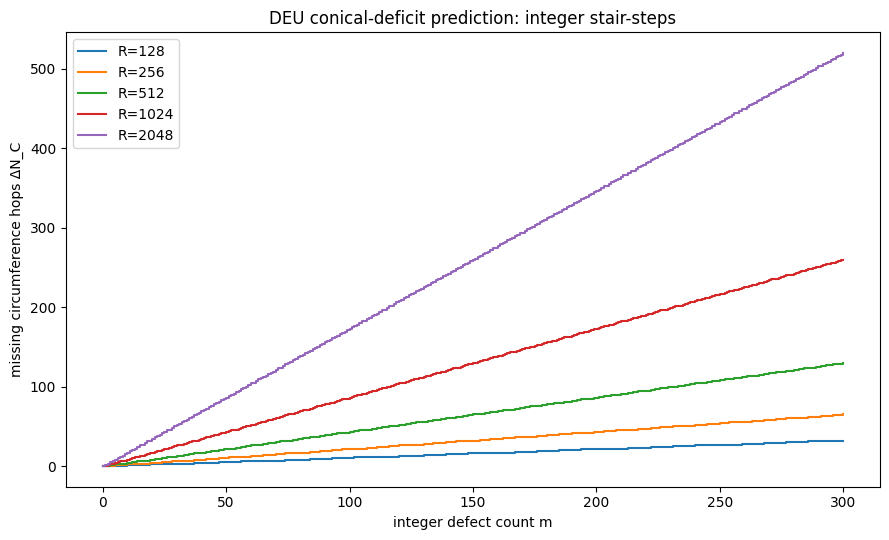

In [5]:

fig, ax = plt.subplots(figsize=(9, 5.5))
for R in R_VALUES:
    sub = sweep[sweep['R'] == R]
    ax.step(sub['m'], sub['Delta_NC'], where='post', label=f'R={R}')
ax.set_xlabel('integer defect count m')
ax.set_ylabel('missing circumference hops ΔN_C')
ax.set_title('DEU conical-deficit prediction: integer stair-steps')
ax.legend()
fig.tight_layout()
plot_path = OUT / 'staircase_delta_nc_vs_mass.png'
fig.savefig(plot_path, dpi=180)
print(f"Saved {plot_path}")
plt.show()



### Reading the stair-step plot

For small radius, one defect is much less than one missing circumference hop, so the shell stores "topological slack" across many injected defects before snapping. For large radius, the same microscopic deficit is magnified by \(R\), so jumps happen more frequently.

This gives a concrete simulation-design rule:

\[
m_{\rm first\ jump}(R)\approx \left\lceil \frac{1}{8\pi G_{\rm DEU} R}\right\rceil.
\]


In [6]:

first_jump_path = OUT / 'first_jump_table.csv'
first_jump.to_csv(first_jump_path, index=False)
print(f"Saved first-jump table to {first_jump_path}")
first_jump


Saved first-jump table to /mnt/data/deu_gr_experiment_01_outputs/first_jump_table.csv


,R,first_m_for_ΔN_C≥1,deficit_per_defect_at_R
0,32,37,0.027103
1,64,19,0.054206
2,128,10,0.108413
3,256,5,0.216825
4,512,3,0.433650
5,1024,2,0.867301
6,2048,1,1.734601
7,4096,1,3.469203


Saved /mnt/data/deu_gr_experiment_01_outputs/g_estimate_from_integer_deficit.png


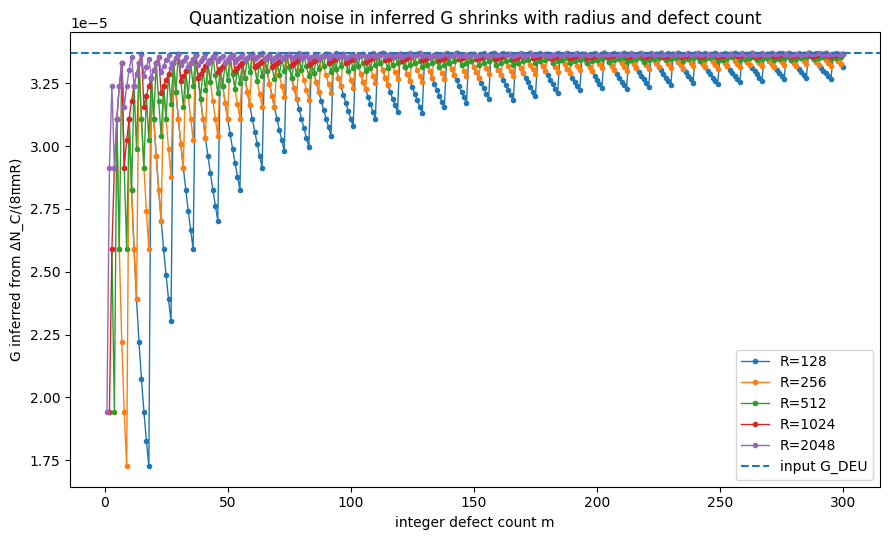

In [7]:

# Estimate G from the quantized deficit. This is noisy at low m because ΔN_C is an integer.
fig, ax = plt.subplots(figsize=(9, 5.5))
for R in R_VALUES:
    sub = sweep[(sweep['R'] == R) & (sweep['m'] > 0) & (sweep['Delta_NC'] > 0)]
    ax.plot(sub['m'], sub['G_hat'], marker='.', linewidth=1, label=f'R={R}')
ax.axhline(G_DEU, linestyle='--', linewidth=1.5, label='input G_DEU')
ax.set_xlabel('integer defect count m')
ax.set_ylabel('G inferred from ΔN_C/(8πmR)')
ax.set_title('Quantization noise in inferred G shrinks with radius and defect count')
ax.legend()
fig.tight_layout()
plot_path = OUT / 'g_estimate_from_integer_deficit.png'
fig.savefig(plot_path, dpi=180)
print(f"Saved {plot_path}")
plt.show()



## 4. Explicit graph sanity check

The previous section used direct shell formulas. This section builds an actual finite graph with concentric shell cycles and radial edges. It is not the full DEU engine; it is a measurement calibration object.

Purpose: verify that a graph measurement based on hop shells recovers the integer circumference deficit.


In [8]:

try:
    import networkx as nx
    HAS_NX = True
except Exception:
    HAS_NX = False
    print('networkx is not installed; skipping explicit graph sanity check')


def build_conical_shell_graph(Rmax: int, m: int, *, kappa: float = KAPPA, mode: RoundingMode = 'floor'):
    """Build a lightweight radial shell graph with circumference counts N_C(R,m).

    Nodes are tuples (r, i), with center (0, 0). Each shell is a cycle. Radial edges map shell r
    to shell r+1 by nearest angular index. BFS distance from the center recovers shell radius.
    """
    if not HAS_NX:
        raise RuntimeError('networkx unavailable')
    if Rmax < 1:
        raise ValueError('Rmax must be positive')

    G = nx.Graph()
    G.add_node((0, 0))

    counts = {0: 1}
    for r in range(1, Rmax + 1):
        n = shell_count_with_deficit(r, m, kappa=kappa, mode=mode)
        counts[r] = n
        for i in range(n):
            G.add_node((r, i))
        # Intra-shell cycle.
        if n > 1:
            for i in range(n):
                G.add_edge((r, i), (r, (i + 1) % n))
        # Radial edges.
        if r == 1:
            for i in range(n):
                G.add_edge((0, 0), (r, i))
        else:
            prev_n = counts[r - 1]
            for i in range(n):
                parent_i = min(prev_n - 1, int(math.floor(i * prev_n / n)))
                G.add_edge((r - 1, parent_i), (r, i))
    return G, counts


def measure_bfs_shell_counts(G, center=(0, 0), Rmax: Optional[int] = None) -> pd.DataFrame:
    """Measure shell sizes from BFS distance."""
    if not HAS_NX:
        raise RuntimeError('networkx unavailable')
    lengths = nx.single_source_shortest_path_length(G, center, cutoff=Rmax)
    rows = []
    for r, count in sorted(pd.Series(lengths).value_counts().items()):
        rows.append({'R': int(r), 'measured_shell_count': int(count)})
    return pd.DataFrame(rows)

RMAX_SANITY = 80
M_SANITY = 50
Ggraph, expected_counts = build_conical_shell_graph(RMAX_SANITY, M_SANITY)
measured = measure_bfs_shell_counts(Ggraph, Rmax=RMAX_SANITY)
expected = pd.DataFrame({
    'R': list(expected_counts.keys()),
    'expected_shell_count': list(expected_counts.values()),
})
check = measured.merge(expected, on='R', how='outer')
check['difference'] = check['measured_shell_count'] - check['expected_shell_count']
print(f"Graph nodes: {Ggraph.number_of_nodes():,}; edges: {Ggraph.number_of_edges():,}")
print(f"Max absolute shell-count error: {check['difference'].abs().max()}")
check.tail(10)


Graph nodes: 19,341; edges: 38,680
Max absolute shell-count error: 0


,R,measured_shell_count,expected_shell_count,difference
71,71,423,423,0
72,72,429,429,0
73,73,435,435,0
74,74,441,441,0
75,75,447,447,0
76,76,453,453,0
77,77,459,459,0
78,78,465,465,0
79,79,471,471,0
80,80,477,477,0


Saved /mnt/data/deu_gr_experiment_01_outputs/explicit_graph_shell_deficit_vs_radius.png


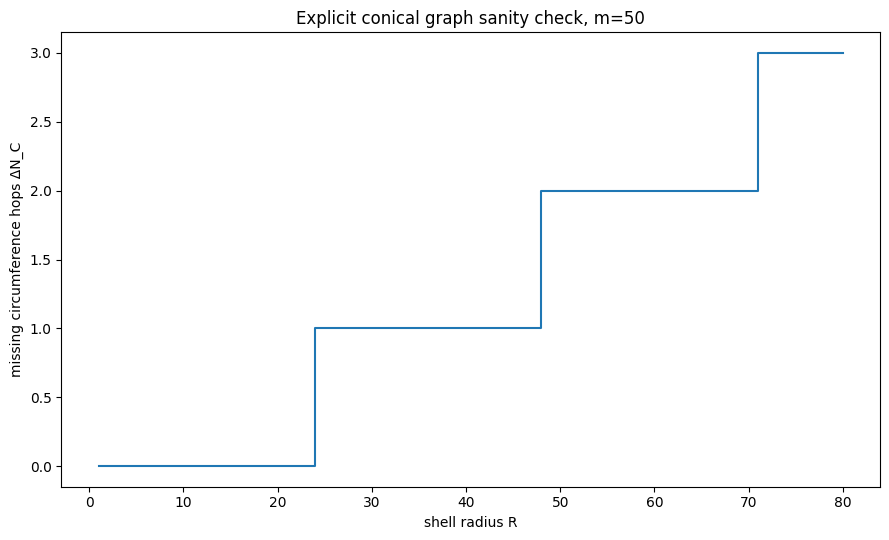

In [9]:

fig, ax = plt.subplots(figsize=(9, 5.5))
check_nonzero = check[check['R'] > 0].copy()
check_nonzero['flat_shell_count'] = check_nonzero['R'].map(triangular_shell_size_flat)
check_nonzero['Delta_NC'] = check_nonzero['flat_shell_count'] - check_nonzero['measured_shell_count']
ax.step(check_nonzero['R'], check_nonzero['Delta_NC'], where='post')
ax.set_xlabel('shell radius R')
ax.set_ylabel('missing circumference hops ΔN_C')
ax.set_title(f'Explicit conical graph sanity check, m={M_SANITY}')
fig.tight_layout()
plot_path = OUT / 'explicit_graph_shell_deficit_vs_radius.png'
fig.savefig(plot_path, dpi=180)
print(f"Saved {plot_path}")
plt.show()



## 5. Real DEU engine analysis hook

When the real DEU/RMR simulation is plugged in, we should produce one row per measured shell:

| column | meaning |
|---|---|
| `seed` | random seed / deterministic run id |
| `cap` | scheduler cap or local bandwidth setting |
| `target_splits` | total splits or epoch horizon |
| `m` | injected persistent defect count |
| `R` | graph-radius shell around defect center |
| `N_C_flat` | baseline vacuum shell count at same `R` and comparable refinement window |
| `N_C_defect` | measured shell count around defect |
| `metric` | raw hop, refinement-weighted, registry-weighted, etc. |

The functions below analyze such a table without knowing how the engine generated it.


In [10]:

def analyze_shell_sweep(df: pd.DataFrame) -> pd.DataFrame:
    """Add deficit and inferred-G columns to a shell-measurement table."""
    required = {'R', 'm', 'N_C_flat', 'N_C_defect'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    out = df.copy()
    out['Delta_NC'] = out['N_C_flat'] - out['N_C_defect']
    out['Delta_theta_graph'] = np.where(out['R'] > 0, out['Delta_NC'] / out['R'], np.nan)
    out['G_hat'] = [inferred_G_from_deficit(int(R), int(m), int(d)) for R, m, d in zip(out['R'], out['m'], out['Delta_NC'])]
    out['is_integer_deficit'] = np.isclose(out['Delta_NC'], np.round(out['Delta_NC']))
    return out

# Demonstrate the hook using the synthetic sweep as if it came from an engine.
engine_like = sweep[['R', 'm', 'N_C_flat', 'N_C_defect']]
analyzed = analyze_shell_sweep(engine_like)
analyzed.head()


,R,m,N_C_flat,N_C_defect,Delta_NC,Delta_theta_graph,G_hat,is_integer_deficit
0,128,0,768,768,0,0.0,NaN,True
1,128,1,768,768,0,0.0,0.0,True
2,128,2,768,768,0,0.0,0.0,True
3,128,3,768,768,0,0.0,0.0,True
4,128,4,768,768,0,0.0,0.0,True



## 6. Unified lapse/clock test hook

The conical-deficit test checks spatial holonomy. The unified SR/GR equation also requires the local clock/lapse check:

\[
\Phi_{\rm moving}(R,m)^2+v^2\approx(1-\Omega(R,m))^2,
\qquad
\Omega(R,m)=1-\Phi_{\rm rest}(R,m).
\]

The real engine should eventually produce probe-clock rows with columns:

| column | meaning |
|---|---|
| `R`, `m` | defect shell |
| `v` | measured lateral split fraction |
| `Phi_rest` | stationary probe internal update fraction |
| `Phi_moving` | moving probe internal update fraction |

The function below computes residuals for that equation. For now, it uses synthetic noisy data only to validate the analysis pathway.


In [11]:

def analyze_lapse_bandwidth(df: pd.DataFrame) -> pd.DataFrame:
    required = {'R', 'm', 'v', 'Phi_rest', 'Phi_moving'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    out = df.copy()
    out['Omega'] = 1.0 - out['Phi_rest']
    out['lhs'] = out['Phi_moving'] ** 2 + out['v'] ** 2
    out['rhs'] = (1.0 - out['Omega']) ** 2
    out['bandwidth_residual'] = out['lhs'] - out['rhs']
    out['relative_residual'] = out['bandwidth_residual'] / out['rhs']
    return out


def make_synthetic_lapse_data(seed: int = 0) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    for R in [256, 512, 1024]:
        for m in [0, 25, 50, 100, 200]:
            # Toy lapse law only; replace with measured stationary clocks.
            Omega = min(0.98, KAPPA * m * R / (6 * R))  # intentionally small; not a claim
            Phi_rest = 1.0 - Omega
            for v_local in [0.0, 0.1, 0.2, 0.35, 0.5]:
                # Use globally normalized v so v must be <= Phi_rest.
                v = min(v_local * Phi_rest, 0.98 * Phi_rest)
                Phi_moving = math.sqrt(max(0.0, Phi_rest**2 - v**2))
                Phi_moving += rng.normal(0, 0.002)
                rows.append({'R': R, 'm': m, 'v': v, 'Phi_rest': Phi_rest, 'Phi_moving': Phi_moving})
    return pd.DataFrame(rows)

lapse_demo = analyze_lapse_bandwidth(make_synthetic_lapse_data())
lapse_demo_path = OUT / 'synthetic_lapse_bandwidth_demo.csv'
lapse_demo.to_csv(lapse_demo_path, index=False)
print(f"Saved synthetic lapse demo to {lapse_demo_path}")
lapse_demo.head()


Saved synthetic lapse demo to /mnt/data/deu_gr_experiment_01_outputs/synthetic_lapse_bandwidth_demo.csv


,R,m,v,Phi_rest,Phi_moving,Omega,lhs,rhs,bandwidth_residual,relative_residual
0,256,0,0.00,1.0,1.000251,0.0,1.000503,1.0,0.000503,0.000503
1,256,0,0.10,1.0,0.994723,0.0,0.999474,1.0,-0.000526,-0.000526
2,256,0,0.20,1.0,0.981077,0.0,1.002512,1.0,0.002512,0.002512
3,256,0,0.35,1.0,0.936959,0.0,1.000393,1.0,0.000393,0.000393
4,256,0,0.50,1.0,0.864954,0.0,0.998146,1.0,-0.001854,-0.001854


Saved /mnt/data/deu_gr_experiment_01_outputs/synthetic_lapse_bandwidth_residuals.png


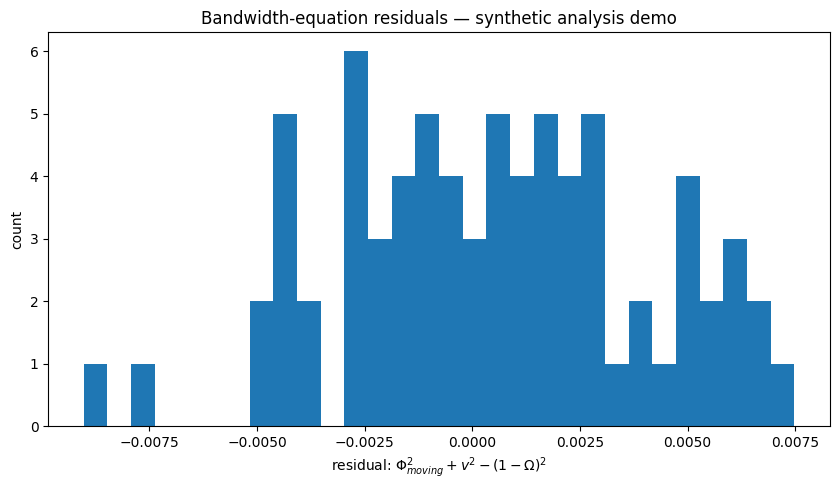

In [12]:

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.hist(lapse_demo['bandwidth_residual'], bins=30)
ax.set_xlabel(r'residual: $\Phi_{moving}^2 + v^2 - (1-\Omega)^2$')
ax.set_ylabel('count')
ax.set_title('Bandwidth-equation residuals — synthetic analysis demo')
fig.tight_layout()
plot_path = OUT / 'synthetic_lapse_bandwidth_residuals.png'
fig.savefig(plot_path, dpi=180)
print(f"Saved {plot_path}")
plt.show()



## 7. What the real DEU run must decide

This notebook has not proven the DEU conical deficit. It has done the useful first step: it fixed the observables, generated the expected integer staircase under the proposed law, and verified that graph-shell measurement can recover integer deficits in an explicit calibration graph.

The first true engine experiment should now run this matrix:

- caps: `128, 256, 512, 1024`, with special attention to the previously good `512` window;
- seeds: at least `10`; preferably `30+`;
- defect counts: enough to cross several predicted stair steps for the chosen radius;
- radii: at least `128, 256, 512, 1024` if the graph is large enough;
- metrics: raw shell count and refinement-weighted/registry-weighted shell count.

Pass condition for Experiment 01:

\[
\Delta N_C(R,m)\in\mathbb Z
\]

is automatic for hop shells, but the nontrivial pass condition is:

\[
\Delta N_C(R,m)\approx\left\lfloor 8\pi G_{\rm DEU}mR+\epsilon_{\rm slack}\right\rfloor
\]

with one fitted \(G_{\rm DEU}\) that is stable across radius, seed, cap, and shell-measurement method.
